In [13]:
# %pip install langchain langgraph pandas ragas -q

In [1]:
import pandas as pd

df = pd.read_csv("gofood_dataset.csv")
# Filter out columns if needed
df = df[['merchant_name', 'merchant_area', 'category', 'product', 'price']]
df.columns.tolist()

# Take only 5000 rows for faster processing and keep a copy for indexing
df = df.head(5000).copy()
df["row_id"] = df.index

In [31]:
df.to_csv("gofood_5000_sample.csv", index=False)

In [20]:
from langchain_core.documents import Document

# Group rows so each restaurant-category pair shares a single document
grouped = (
    df.groupby(["merchant_name", "category"], as_index=False)
      .agg({
          "merchant_area": "first",
          "product": list,
          "price": list,
          "row_id": list,
      })
)

documents = []
for _, row in grouped.iterrows():
    restaurant_name = str(row['merchant_name'])
    category = str(row['category'])
    products = [str(p) for p in row['product']]
    prices = [str(p) for p in row['price']]

    product_lines = "\n".join(
        f"- {product} | Harga: {price}"
        for product, price in zip(products[:5], prices[:5])
    ) or "- (Produk belum tersedia)"

    text = f"""
    Pertanyaan: Saya ingin {category}. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: {restaurant_name}\nKategori: {category}\nProduk & Harga:\n{product_lines}
    """
    documents.append(
        Document(
            page_content=text,
            metadata={
                "source_rows": [int(idx) for idx in row['row_id']],
                "merchant_area": str(row['merchant_area'])
            }
        )
    )

print(f"Total documents: {len(documents)}")
print(f"Sample document:\n{documents[0].page_content}")
print(f"Metadata of sample document:\n{documents[0].metadata}")

Total documents: 79
Sample document:

    Pertanyaan: Saya ingin Kopi/Minuman/Roti. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: 330 Kopi, Ciledug
Kategori: Kopi/Minuman/Roti
Produk & Harga:
- Hot Almara Kopi (kopi Susu Gula Aren) | Harga: 20000.0
- Ice Almara Kopi (kopi Susu Gula Aren) | Harga: 22000.0
- Hot Millsis | Harga: 20000.0
- Ice Millsis | Harga: 20000.0
- Hot Millbro | Harga: 22000.0
    
Metadata of sample document:
{'source_rows': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63], 'merchant_area': 'jakarta'}


In [3]:
# %pip install langchain-ollama -qU

from langchain_ollama import ChatOllama

# jika Ollama serve default di localhost:11434, wrapper akan memakai itu
llm = ChatOllama(model="gpt-oss:120b-cloud")  # ganti model sesuai yang sudah kamu pull
print(llm)

c:\SEMESTER_3\Materi NLPLLM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model='gpt-oss:120b-cloud'


In [4]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="all-minilm:22m",
)
print(embeddings)

model='all-minilm:22m' validate_model_on_init=False base_url=None client_kwargs={} async_client_kwargs={} sync_client_kwargs={} mirostat=None mirostat_eta=None mirostat_tau=None num_ctx=None num_gpu=None keep_alive=None num_thread=None repeat_last_n=None repeat_penalty=None temperature=None stop=None tfs_z=None top_k=None top_p=None


In [22]:
# Create a vector store with a sample text
from langchain_core.vectorstores import InMemoryVectorStore

vectorstore = InMemoryVectorStore.from_documents(
    documents,
    embedding=embeddings,
)

# Use the vectorstore as a retriever
retriever = vectorstore.as_retriever()

# Retrieve the most similar text
retrieved_documents = retriever.invoke("Saya ingin ayam")

# Show the retrieved document's content and metadata
print("Retrieved Document Content:")
print(retrieved_documents[0].page_content)
print(retrieved_documents[0].metadata)

Retrieved Document Content:

    Pertanyaan: Saya ingin Aneka nasi/Ayam & bebek/Seafood. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Ayam Trolok
Kategori: Aneka nasi/Ayam & bebek/Seafood
Produk & Harga:
- Ayam Full | Harga: 100000.0
- Nasi | Harga: 6000.0
- Ayam Dada | Harga: 25000.0
- Ayam Paha | Harga: 25000.0
- Kepala Ayam | Harga: 6000.0
    
{'source_rows': [259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275], 'merchant_area': 'jakarta'}


In [23]:
docs_with_scores = vectorstore.similarity_search_with_score("Saya ingin bakso", k=5)
for doc, score in docs_with_scores:
    print(f"Content: {doc.page_content}")
    print(f"Score: {score:.3f}")  # Lower = more similar
    print("---")


Content: 
    Pertanyaan: Saya ingin Bakso & soto/Minuman. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Bakso Titoti, Parung
Kategori: Bakso & soto/Minuman
Produk & Harga:
- Ayam Kampung Goreng Kremes | Harga: 31500.0
- Ayam Kampung Goreng Kremes + Nasi | Harga: 36500.0
- Bakso Mie Campur | Harga: 29000.0
- Bakso Soun/Bihun/Mie Kuning | Harga: 29000.0
- Bakso Spesial | Harga: 39000.0
    
Score: 0.481
---
Content: 
    Pertanyaan: Saya ingin Roti. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Cake Pandeglang Cake
Kategori: Roti
Produk & Harga:
- BF Love Cok Tempel Uk 20cm | Harga: 155000.0
- Bf Kotak Cok Tempel Uk 20cm | Harga: 155000.0
- BF Bulat Ukir Tayo Uk20cm | Harga: 160000.0
- BF Bulat Ukir Doraemon Uk20cm | Harga: 160000.0
- Bf Bulat Ukir Hello Kitty Uk20cm | Harga: 160000.0
    
Score: 0.438
---
Content: 
    Pertanyaan: Saya ingin Ay

In [7]:
from textwrap import shorten

SYSTEM_INSTR="""
Kamu adalah asisten yang sangat membantu untuk merekomendasikan tempat makan berdasarkan keinginan pengguna.

Kamu akan memberikan rekomendasi tempat makan yang sesuai dengan keinginan pengguna berdasarkan data yang kamu miliki.

Susun ulang dengan bahasa yang menarik dan informatif.
Jika tidak ada rekomendasi yang sesuai, katakan bahwa "Mohon maaf, tidak dapat menemukan rekomendasi yang sesuai."
"""

def build_prompt(user_q, retrieved, prompt_tambahan):
    # build a context string listing retrieved items with small excerpts
    context_blocks = []
    for i, r in enumerate(retrieved, 1):
        # limit length to avoid too long prompt
        context_blocks.append(f"[{i}] {str(r)}")
    context = "\n\n".join(context_blocks)
    prompt = (
        SYSTEM_INSTR + "\n\n" +
        f"Context (reference QA pairs):\n{context}\n\n"
        f"Pertanyaan pengguna: {user_q}\n\n" + prompt_tambahan
    )
    # print (prompt)
    return prompt


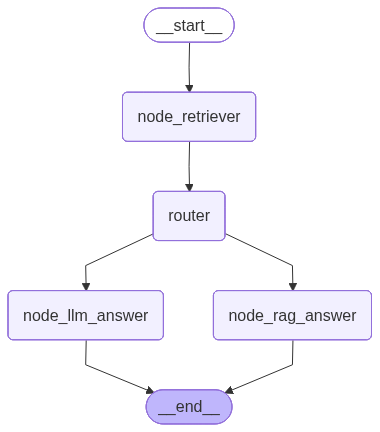

In [25]:
### LANGGRAPH

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from ragas.metrics.collections import BleuScore
from IPython.display import Image


class State(TypedDict):
    query: str
    answer: str
    llm_answer: str
    score: float
    k: int
    retrieved: str
    prompt: str
    bleu_score: float

def node_retriever(state):
    query = state["query"]
    k = state["k"]
    docs_with_score = vectorstore.similarity_search_with_score(query, k)

    # Ambil dokumen dengan score terbesar (paling mirip)
    best_idx = docs_with_score.index(max(docs_with_score, key=lambda x: x[1]))
    best_doc = docs_with_score[best_idx][0].page_content
    best_score = float(docs_with_score[best_idx][1])
    retrieved_list = [doc.page_content for doc, score in docs_with_score]
    return {"retrieved": retrieved_list, "score": best_score}
    
# --- NODE: router ---
def router(state: State):
    return {"next_node": ["node_rag_answer", "node_llm_answer"]}

def node_fallback(state: State):
    ans = "Mohon maaf saya tidak bisa menjawab pertanyaan ini karena di luar konteks yang saya pahami."
    retrieved = ""
    prompt = state["query"]
    return {"answer": ans, "retrieved": retrieved, "prompt": prompt}

async def node_llm_answer(state: State):
    q = state["query"]
    prompt = build_prompt(q, [], "Jawab pertanyaan di atas dengan singkat dan jelas.")
    llm_out = await llm.ainvoke([{"role": "user", "content": prompt}])
    return {"llm_answer": [HumanMessage(content=llm_out.content)], "prompt": prompt}

async def node_rag_answer(state: State):
    q = state["query"]
    k = state["k"]
    retrieved = state["retrieved"]
    scorer = BleuScore()
    # prompt_tambahan = ("Gunakan konteks di atas sekaligus lakukan pencarian di web terkait pertanyaan user untuk menyusun jawaban baru."
    # "Jawaban juga harus mencantumkan link URL valid dari website terkait yang menjadi sumber jawaban sebagai bagian dari catatan tambahan / tips penting.")
    prompt_tambahan = ("Gunakan konteks di atas sebagai dasar jawaban kamu, rekomendasikan cara memesan dan langkah selanjutnya.")
    prompt = build_prompt(q, retrieved, prompt_tambahan)

    context = vectorstore.as_retriever().invoke(q, k=k)
    context = [doc.page_content for doc in context]

    llm_out = await llm.ainvoke([{"role": "user", "content": prompt}])

    ctx_lines = [line.strip() for line in "\n".join(context).splitlines() if line.strip()]
    resp_tokens = set(llm_out.content.lower().split())
    selected = []
    for line in ctx_lines:
        line_tokens = set(line.lower().split())
        overlap = len(resp_tokens & line_tokens) / (len(line_tokens) + 1e-6)
        if overlap > 0.2:  # keep lines with decent lexical overlap
            selected.append(line)
    reference_text = "\n".join(selected) if selected else llm_out.content

    bleu_score = await scorer.ascore(reference=reference_text, response=llm_out.content)
    state["bleu_score"] = bleu_score
    # llm_out may be LangChain object/string; convert to string if needed
    # ans = llm_out if isinstance(llm_out, str) else str(llm_out)
    return {"answer": [HumanMessage(content=llm_out.content)], "retrieved": retrieved, "bleu_score": bleu_score}

# --- BANGUN GRAPH ---
graph = StateGraph(State)
graph.add_node("node_retriever", node_retriever)
graph.add_node("router", router)
graph.add_node("node_rag_answer", node_rag_answer)
graph.add_node("node_llm_answer", node_llm_answer) 

graph.set_entry_point("node_retriever")
graph.add_edge("node_retriever", "router")
graph.add_edge("router", "node_rag_answer")
graph.add_edge("router", "node_llm_answer")

# mapping edge berdasarkan nilai "route"
# graph.add_conditional_edges(
#     "router",
#     lambda state: state["next_node"],
#     {
#         "node_rag_answer": "node_combine",
#         "node_llm_answer": "node_combine"
#     }
# )
# graph.add_edge("node_combine", END)

app = graph.compile()

# Visualize the graph
display((Image(app.get_graph().draw_mermaid_png())))


In [30]:
from IPython.display import Markdown, display

print("RAG chatbot siap. Ketik 'exit' untuk keluar.")
while True:
    q = input("Tanya: ").strip()
    if q.lower() in ("exit","quit"):
        break
    res = await app.ainvoke({"query": q, "k": 3})
    
    # Display score
    display(Markdown(f"### Similarity Score: {res['score']:.4f}"))
    display(Markdown(f"### Bleu Score: {res['bleu_score'].value:.4f}"))
    
    # Display answer
    answer_text = res["answer"][0].content if isinstance(res["answer"], list) else str(res["answer"])
    display(Markdown(f"### Jawaban RAG:\n{answer_text}"))

    llm_answer_text = res["llm_answer"][0].content if isinstance(res["llm_answer"], list) else str(res["llm_answer"])
    display(Markdown(f"### Jawaban LLM:\n{llm_answer_text}"))

    # Display retrieved sources
    display(Markdown("### Sumber Referensi:"))
    retrieved_list = list(res["retrieved"])
    for i, r in enumerate(retrieved_list, 1):
        display(Markdown(f"{r}"))
    
    print("\n---\n")


RAG chatbot siap. Ketik 'exit' untuk keluar.


### Similarity Score: 0.5734

### Bleu Score: 0.1477

### Jawaban RAG:
**🍔 Rekomendasi Restoran Burger: Burger Naura**  

**Kategori:** Jajanan / Cepat Saji / Bakso & Soto  

### 🥳 Menu Unggulan & Harga
| Produk | Harga (IDR) |
|--------|------------|
| Paket 2 Burger, Kentang, Sosis, Otak‑Otak | **20.000** |
| Paket 1 Burger + Kentang + Otak‑Otak | **17.000** |
| Burger + Sosis | **17.000** |
| Paket 1 Burger, Sosis Medium, Kentang, Double Mayonaise & Saus | **18.000** |
| Paket 3 Burger | **25.000** |

> *Semua paket sudah termasuk kentang renyah atau saus pilihan, cocok untuk makan cepat, santai, ataupun acara kumpul‑kumpul kecil.*

### 📍 Cara Memesan & Langkah Selanjutnya
1. **Pesan via Aplikasi Pengantar**  
   - Cari “Burger Naura” di **GoFood**, **GrabFood**, atau **ShopeeFood**.  
   - Pilih paket yang Anda suka, sesuaikan tambahan (extra saus, napkin, atau minuman).  
   - Checkout dan pilih waktu pengantaran (segera atau jadwalkan).

2. **Telepon / WhatsApp Langsung**  
   - Jika ingin konfirmasi ketersediaan atau pakai layanan catering, hubungi mereka lewat nomor telepon yang biasanya tertera di profil aplikasi atau di Google Maps.  
   - Sampaikan paket yang diinginkan, jumlah porsi, dan alamat pengiriman.

3. **Datang Langsung**  
   - Alamat lengkap dapat dicek di Google Maps dengan pencarian “Burger Naura”.  
   - Datanglah pada jam operasional (biasanya 10.00 – 22.00) untuk menikmati burger panas langsung dari dapur.

4. **Pembayaran**  
   - **Online:** OVO, GoPay, ShopeePay, atau kartu debit/kredit melalui aplikasi.  
   - **Di Tempat:** Cash atau e‑money (jika datang langsung).

5. **Konfirmasi & Review**  
   - Setelah menerima pesanan, cek kembali kualitas dan kuantitas.  
   - Beri rating di aplikasi atau beri ulasan singkat di media sosial restoran – ini membantu mereka meningkatkan layanan dan memberi Anda poin reward.

### 🎉 Tips Tambahan
- **Promo & Diskon:** Aplikasi pengantar sering kali mengadakan “Free Delivery” atau potongan harga untuk paket burger di hari‑hari tertentu. Pantau bagian “Deals”.
- **Paket Besar:** Untuk acara kantor atau gathering, tanyakan paket catering (misalnya 10 + burger + minuman) yang biasanya mendapat diskon khusus.
- **Varian Saus:** Jangan ragu minta ekstra saus pedas atau mayo – kebanyakan “burger lovers” menyukainya!

Selamat menikmati kelezatan Burger Naura! 🚀 Jika ada pertanyaan lain seputar menu atau cara pemesanan, silakan beri tahu saya.

### Jawaban LLM:
Berikut beberapa rekomendasi restoran burger yang patut dicoba:

| Nama Restoran | Lokasi | Kelebihan Utama |
|---------------|--------|-----------------|
| **Burger Lab** | Jakarta Selatan (SCBD) | Burger abon premium, roti berlapis keju lembut |
| **The Good Burger** | Bandung (Jl. Braga) | Patty daging sapi 100 % lokal, pilihan saus kreatif |
| **Ovenly Burger** | Surabaya (Gubeng) | Burger panggang oven, menu vegetarian & vegan |
| **Mr. B’s** | Yogyakarta (Malioboro) | Porsi besar, combo burger + kentang goreng renyah |
| **Crafted Burger** | Bali (Seminyak) | Bahan organik, atmosfer cosy dengan view pantai |

Silakan pilih sesuai selera dan lokasi Anda. Selamat menikmati!

### Sumber Referensi:


    Pertanyaan: Saya ingin Jajanan/Cepat saji/Bakso & soto. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Burger Naura
Kategori: Jajanan/Cepat saji/Bakso & soto
Produk & Harga:
- Paket, 2 Burger, Kentang, Sosis, Otak Otak | Harga: 20000.0
- Paket 1 Burger Dan Kentang Otak Otak | Harga: 17000.0
- Burger+sosis | Harga: 17000.0
- Paket, 1 Burger, Sosis Medium, Kentang, Doble Mayonaise Dan Saus | Harga: 18000.0
- Paket 3 Burger | Harga: 25000.0
    


    Pertanyaan: Saya ingin Sweets/Barat/Minuman. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Holywings Backyard, Kemang
Kategori: Sweets/Barat/Minuman
Produk & Harga:
- Crispy Hot Fried Chicken Wings | Harga: 82500.0
- Hand Cut Fries W/ Smoked Paprika Salt | Harga: 44000.0
- Marinara Beef Meatballs | Harga: 101200.0
- Chitato Nachos | Harga: 71500.0
- Hand Cut Loaded Fries | Harga: 66000.0
    


    Pertanyaan: Saya ingin Jajanan. Rekomendasikan saya tempat untuk membelinya, termasuk produk dan harganya.

    Referensi Jawaban:
    Nama Restoran: Kebab Bosman, Ciputat
Kategori: Jajanan
Produk & Harga:
- Special Kebab Original Jumbo | Harga: 13000.0
- Special Kebab Keju | Harga: 13500.0
- Special Burger Keju | Harga: 13500.0
- Special Hotdog Keju | Harga: 13500.0
- Canai Kecok Extra Keju | Harga: 13500.0
    


---



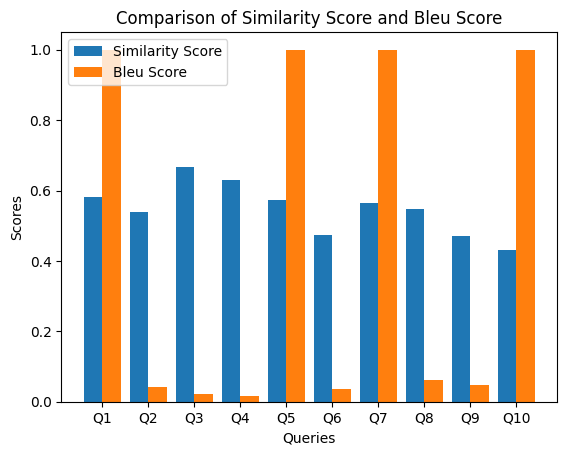

<Figure size 640x480 with 0 Axes>

In [26]:
from IPython.display import display, Markdown
queries = [
    "Saya ingin jajanan makanan khas Indonesia.",
    "Rekomendasikan saya tempat untuk membeli makanan Jepang.",
    "Dimana saya bisa mendapatkan pizza enak?",
    "Saya mencari restoran yang menjual burger.",
    "Ada rekomendasi tempat untuk makanan vegetarian?",
    "Dimana saya bisa membeli makanan penutup yang lezat?",
    "Saya ingin mencoba masakan Thailand.",
    "Rekomendasikan tempat untuk makanan cepat saji.",
    "Dimana saya bisa mendapatkan makanan laut segar?",
    "Saya mencari restoran yang menyajikan masakan Italia."
]
import matplotlib.pyplot as plt
similarity_scores = []
bleu_scores = []

results = []
for q in queries:
    res = await app.ainvoke({"query": q, "k": 3})
    similarity_scores.append(res['score'])
    bleu_scores.append(res['bleu_score'].value)
    
    answer_rag = res["answer"][0].content if isinstance(res["answer"], list) else str(res["answer"])
    answer_llm = res["llm_answer"][0].content if isinstance(res["llm_answer"], list) else str(res["llm_answer"])
    
    results.append({
        "query": q,
        "retrieved_documents": "\n".join(res["retrieved"]),
        "answer_rag": answer_rag,
        "answer_llm": answer_llm,
        "similarity_score": res['score'],
        "bleu_score": res['bleu_score'].value,
    })
    
    # Display results
    # display(Markdown(f"## Query: {q}"))
    # display(Markdown(f"### Similarity Score: {res['score']:.4f}"))
    # display(Markdown(f"### Bleu Score: {res['bleu_score'].value:.4f}"))
    # display(Markdown(f"### Jawaban RAG:\n{answer_rag}"))
    # display(Markdown(f"### Jawaban LLM:\n{answer_llm}"))

# Plot comparison chart
x = range(len(queries))
plt.bar(x, similarity_scores, width=0.4, label='Similarity Score', align='center')
plt.bar([i + 0.4 for i in x], bleu_scores, width=0.4, label='Bleu Score', align='center')
plt.xticks([i + 0.2 for i in x], [f"Q{i+1}" for i in x])
plt.xlabel('Queries')
plt.ylabel('Scores')
plt.title('Comparison of Similarity Score and Bleu Score')
plt.legend()
plt.show()
plt.savefig('rag_score_comparison.png')

# Export results to CSV
import csv
with open('rag_evaluation_results.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=["query", "retrieved_documents", "answer_rag", "answer_llm", "similarity_score", "bleu_score"])
    writer.writeheader()
    for row in results:
        writer.writerow(row)